# 🔋 배터리 열화 분석 데이터 전처리

## 목표
- metadata.csv에서 타겟 배터리 4개(B0005, B0006, B0007, B0018) 데이터 추출
- 결측치 및 이상치 탐지 및 처리
- 파생 컬럼 생성: Cycle, RUL, EOL, SOH
- Tableau 분석용 클린 데이터셋 생성

## 1. 라이브러리 Import 및 기본 설정

In [79]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ast
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (12, 6)

# 시각화 설정
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10
sns.set_style('whitegrid')

# 판다스 출력 옵션
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.4f}'.format)

# 한글 폰트 설정 (맑은 고딕)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

print("✅ 라이브러리 로드 완료!")

✅ 라이브러리 로드 완료!


## 2. 원본 데이터 로드

In [80]:
# 원본 메타데이터 로드
df_raw = pd.read_csv('metadata.csv')

print("="*80)
print("📊 원본 데이터 기본 정보")
print("="*80)
print(f"총 행 수: {len(df_raw):,}")
print(f"총 컬럼 수: {len(df_raw.columns)}")
print(f"배터리 종류: {df_raw['battery_id'].nunique()}개")
print(f"\n데이터 크기: {df_raw.shape}")

📊 원본 데이터 기본 정보
총 행 수: 7,565
총 컬럼 수: 10
배터리 종류: 34개

데이터 크기: (7565, 10)


In [81]:
# 데이터 미리보기
print("\n📋 데이터 미리보기 (처음 5행)")
df_raw.head()


📋 데이터 미리보기 (처음 5행)


,type,start_time,ambient_temperature,battery_id,test_id,uid,filename,Capacity,Re,Rct
0,discharge,[2010. 7. 21. 15. 0. ...,4,B0047,0,1,00001.csv,1.6743047446975208,NaN,NaN
1,impedance,[2010. 7. 21. 16. 53. ...,24,B0047,1,2,00002.csv,NaN,0.05605783343888099,0.20097016584458333
2,charge,[2010. 7. 21. 17. 25. ...,4,B0047,2,3,00003.csv,NaN,NaN,NaN
3,impedance,[2010 7 21 20 31 5],24,B0047,3,4,00004.csv,NaN,0.05319185850921101,0.16473399914864734
4,discharge,[2.0100e+03 7.0000e+00 2.1000e+01 2.1000e+01 2...,4,B0047,4,5,00005.csv,1.5243662105099023,NaN,NaN


In [82]:
# 컬럼 정보
print("\n📝 컬럼 정보")
df_raw.info()


📝 컬럼 정보
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7565 entries, 0 to 7564
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   type                 7565 non-null   object
 1   start_time           7565 non-null   object
 2   ambient_temperature  7565 non-null   int64 
 3   battery_id           7565 non-null   object
 4   test_id              7565 non-null   int64 
 5   uid                  7565 non-null   int64 
 6   filename             7565 non-null   object
 7   Capacity             2794 non-null   object
 8   Re                   1956 non-null   object
 9   Rct                  1956 non-null   object
dtypes: int64(3), object(7)
memory usage: 591.1+ KB



🔋 배터리별 데이터 개수
battery_id
B0005    616
B0006    616
B0007    616
B0018    319
B0025     80
B0026     80
B0027     80
B0028     80
B0029     97
B0030     97
B0031     97
B0032     97
B0033    486
B0034    486
B0036    486
B0038    122
B0039    122
B0040    122
B0041    163
B0042    275
B0043    275
B0044    275
B0045    184
B0046    184
B0047    184
B0048    184
B0049     62
B0050     62
B0051     62
B0052     62
B0053    137
B0054    253
B0055    252
B0056    252
Name: count, dtype: int64


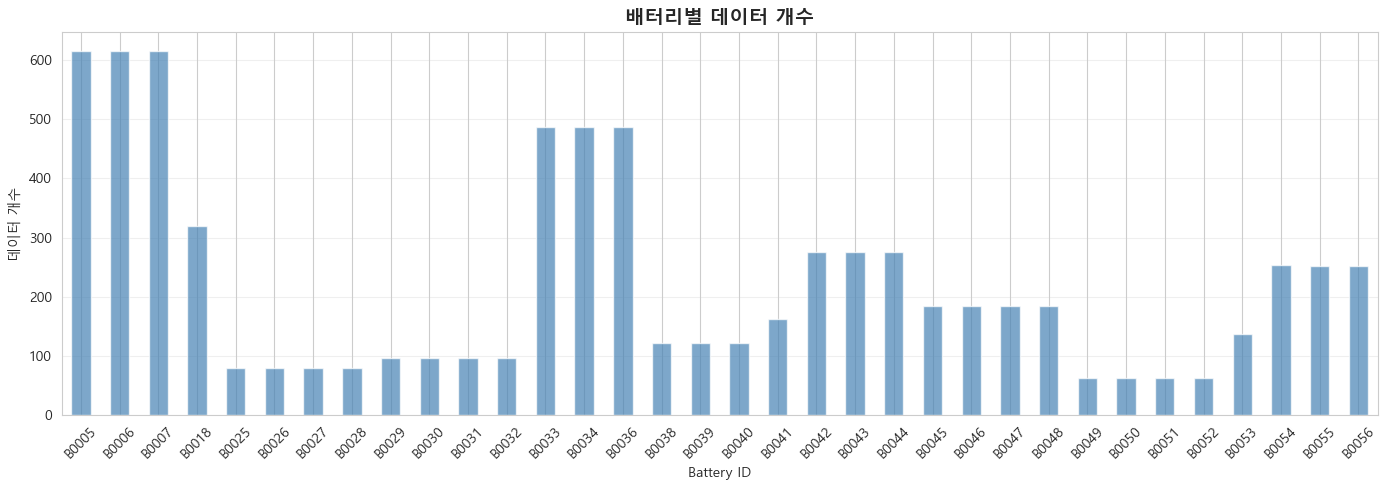

In [83]:
# 배터리별 데이터 분포
print("\n🔋 배터리별 데이터 개수")
battery_counts = df_raw['battery_id'].value_counts().sort_index()
print(battery_counts)

# 시각화
plt.figure(figsize=(14, 5))
battery_counts.plot(kind='bar', color='steelblue', alpha=0.7)
plt.title('배터리별 데이터 개수', fontsize=14, fontweight='bold')
plt.xlabel('Battery ID')
plt.ylabel('데이터 개수')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 3. 타겟 배터리 추출 (B0005, B0006, B0007, B0018)

In [84]:
# 타겟 배터리 정의
TARGET_BATTERIES = ['B0005', 'B0006', 'B0007', 'B0018']

# 필터링
df = df_raw[df_raw['battery_id'].isin(TARGET_BATTERIES)].copy()

print("="*80)
print("🎯 타겟 배터리 추출 완료")
print("="*80)
print(f"전체 데이터: {len(df_raw):,}개 → 필터링 후: {len(df):,}개")
print(f"감소율: {(1 - len(df)/len(df_raw)) * 100:.1f}%")
print(f"\n타겟 배터리별 개수:")
print(df['battery_id'].value_counts().sort_index())

🎯 타겟 배터리 추출 완료
전체 데이터: 7,565개 → 필터링 후: 2,167개
감소율: 71.4%

타겟 배터리별 개수:
battery_id
B0005    616
B0006    616
B0007    616
B0018    319
Name: count, dtype: int64


In [85]:
# 데이터 미리보기
df.head(10)

,type,start_time,ambient_temperature,battery_id,test_id,uid,filename,Capacity,Re,Rct
4504,charge,[2.0080e+03 4.0000e+00 2.0000e+00 1.3000e+01 8...,24,B0006,0,4505,04505.csv,NaN,NaN,NaN
4505,discharge,[2.0080e+03 4.0000e+00 2.0000e+00 1.5000e+01 2...,24,B0006,1,4506,04506.csv,2.035337591005598,NaN,NaN
4506,charge,[2.0080e+03 4.0000e+00 2.0000e+00 1.6000e+01 3...,24,B0006,2,4507,04507.csv,NaN,NaN,NaN
4507,discharge,[2.0080e+03 4.0000e+00 2.0000e+00 1.9000e+01 4...,24,B0006,3,4508,04508.csv,2.0251402460314116,NaN,NaN
4508,charge,[2.0080e+03 4.0000e+00 2.0000e+00 2.0000e+01 5...,24,B0006,4,4509,04509.csv,NaN,NaN,NaN
4509,discharge,[2.008e+03 4.000e+00 3.000e+00 0.000e+00 1.000...,24,B0006,5,4510,04510.csv,2.013326371345464,NaN,NaN
4510,charge,[2.0080e+03 4.0000e+00 3.0000e+00 1.0000e+00 1...,24,B0006,6,4511,04511.csv,NaN,NaN,NaN
4511,discharge,[2008. 4. 3. 4. 16. ...,24,B0006,7,4512,04512.csv,2.0132846655407413,NaN,NaN
4512,charge,[2008. 4. 3. 5. 27. ...,24,B0006,8,4513,04513.csv,NaN,NaN,NaN
4513,discharge,[2008. 4. 3. 8. 33. ...,24,B0006,9,4514,04514.csv,2.000528337624771,NaN,NaN


## 4. 결측치 분석 및 처리

In [86]:
print("="*80)
print("🔍 결측치 분석")
print("="*80)

# 결측치 개수 및 비율 계산
missing_count = df.isnull().sum()
missing_pct = (missing_count / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    '결측 개수': missing_count,
    '결측 비율(%)': missing_pct,
    '데이터 타입': df.dtypes
})

# 결측치가 있는 컬럼만 출력
missing_df_filtered = missing_df[missing_df['결측 개수'] > 0].sort_values('결측 개수', ascending=False)

if len(missing_df_filtered) > 0:
    print("\n⚠️ 결측치가 있는 컬럼:")
    print(missing_df_filtered)
else:
    print("\n✅ 결측치가 없습니다!")

# 전체 결측치 요약
print(f"\n총 결측치 개수: {missing_count.sum():,}")
print(f"결측치 비율: {(missing_count.sum() / (len(df) * len(df.columns)) * 100):.2f}%")

🔍 결측치 분석

⚠️ 결측치가 있는 컬럼:
          결측 개수  결측 비율(%)  데이터 타입
Capacity   1531   70.6500  object
Re         1280   59.0700  object
Rct        1280   59.0700  object

총 결측치 개수: 4,091
결측치 비율: 18.88%


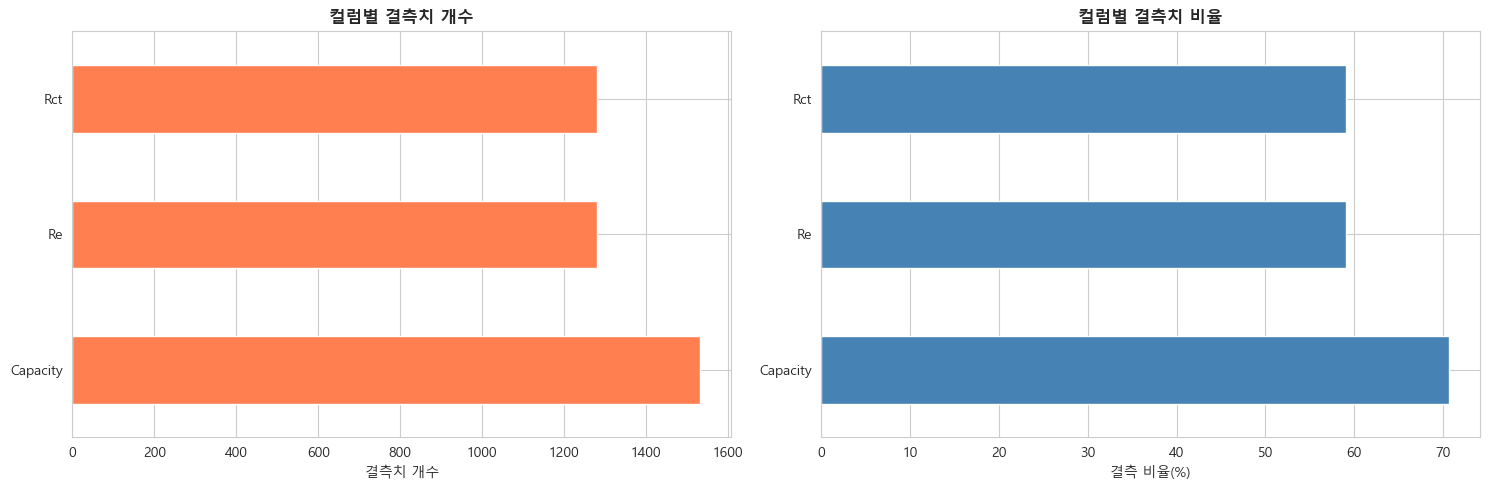

In [87]:
# 결측치 시각화
if missing_count.sum() > 0:
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    
    # 결측치 개수
    missing_df_filtered['결측 개수'].plot(kind='barh', ax=axes[0], color='coral')
    axes[0].set_title('컬럼별 결측치 개수', fontweight='bold')
    axes[0].set_xlabel('결측치 개수')
    
    # 결측치 비율
    missing_df_filtered['결측 비율(%)'].plot(kind='barh', ax=axes[1], color='steelblue')
    axes[1].set_title('컬럼별 결측치 비율', fontweight='bold')
    axes[1].set_xlabel('결측 비율(%)')
    
    plt.tight_layout()
    plt.show()

### 4.1 데이터 타입 변환 (결측치 처리를 위한 사전작업)

In [88]:
print("="*80)
print("🔄 데이터 타입 변환")
print("="*80)

# 숫자형 컬럼 변환
numeric_columns = ['Capacity', 'Re', 'Rct']

for col in numeric_columns:
    before_type = df[col].dtype
    df[col] = pd.to_numeric(df[col], errors='coerce')
    after_type = df[col].dtype
    
    print(f"{col}: {before_type} → {after_type}")

print("\n✅ 데이터 타입 변환 완료!")

🔄 데이터 타입 변환
Capacity: object → float64
Re: object → float64
Rct: object → float64

✅ 데이터 타입 변환 완료!


### 4.2 결측치 처리 전략

In [89]:
print("="*80)
print("📋 결측치 처리 전략")
print("="*80)

# Type별 결측치 패턴 확인
print("\n1️⃣ Type별 Capacity 결측 패턴:")
capacity_missing_by_type = df.groupby('type')['Capacity'].apply(
    lambda x: f"{x.isnull().sum()} / {len(x)} ({x.isnull().sum()/len(x)*100:.1f}%)"
)
print(capacity_missing_by_type)

print("\n2️⃣ Type별 Re 결측 패턴:")
re_missing_by_type = df.groupby('type')['Re'].apply(
    lambda x: f"{x.isnull().sum()} / {len(x)} ({x.isnull().sum()/len(x)*100:.1f}%)"
)
print(re_missing_by_type)

print("\n3️⃣ Type별 Rct 결측 패턴:")
rct_missing_by_type = df.groupby('type')['Rct'].apply(
    lambda x: f"{x.isnull().sum()} / {len(x)} ({x.isnull().sum()/len(x)*100:.1f}%)"
)
print(rct_missing_by_type)

📋 결측치 처리 전략

1️⃣ Type별 Capacity 결측 패턴:
type
charge       644 / 644 (100.0%)
discharge        0 / 636 (0.0%)
impedance    887 / 887 (100.0%)
Name: Capacity, dtype: object

2️⃣ Type별 Re 결측 패턴:
type
charge       644 / 644 (100.0%)
discharge    636 / 636 (100.0%)
impedance        0 / 887 (0.0%)
Name: Re, dtype: object

3️⃣ Type별 Rct 결측 패턴:
type
charge       644 / 644 (100.0%)
discharge    636 / 636 (100.0%)
impedance        0 / 887 (0.0%)
Name: Rct, dtype: object


In [90]:
print("\n💡 결측치 처리 방침:")
print("-" * 80)
print("1. Capacity: discharge 타입에서만 측정되므로 결측은 정상 (유지)")
print("2. Re, Rct: impedance 타입에서만 측정되므로 결측은 정상 (유지)")
print("3. 모든 결측치는 도메인 지식상 정상적인 패턴이므로 그대로 유지")
print("\n⚠️ 주의: 분석 시 type별로 필터링하여 사용해야 함!")


💡 결측치 처리 방침:
--------------------------------------------------------------------------------
1. Capacity: discharge 타입에서만 측정되므로 결측은 정상 (유지)
2. Re, Rct: impedance 타입에서만 측정되므로 결측은 정상 (유지)
3. 모든 결측치는 도메인 지식상 정상적인 패턴이므로 그대로 유지

⚠️ 주의: 분석 시 type별로 필터링하여 사용해야 함!


## 5. 이상치 탐지 및 처리

In [91]:
print("="*80)
print("🔍 이상치 탐지")
print("="*80)

🔍 이상치 탐지


### 5.1 Capacity 이상치 분석

In [92]:
# Capacity 데이터만 추출
capacity_data = df[df['Capacity'].notna()].copy()

print("\n1️⃣ Capacity 기본 통계")
print("-" * 80)
print(capacity_data['Capacity'].describe())

# 배터리별 Capacity 통계
print("\n2️⃣ 배터리별 Capacity 통계")
print("-" * 80)
battery_capacity_stats = capacity_data.groupby('battery_id')['Capacity'].describe()
print(battery_capacity_stats)


1️⃣ Capacity 기본 통계
--------------------------------------------------------------------------------
count   636.0000
mean      1.5817
std       0.1988
min       1.1538
25%       1.4211
50%       1.5597
75%       1.7635
max       2.0353
Name: Capacity, dtype: float64

2️⃣ 배터리별 Capacity 통계
--------------------------------------------------------------------------------
              count   mean    std    min    25%    50%    75%    max
battery_id                                                          
B0005      168.0000 1.5725 0.1904 1.2875 1.3900 1.5571 1.7692 1.8565
B0006      168.0000 1.5469 0.2520 1.1538 1.3474 1.4854 1.7672 2.0353
B0007      168.0000 1.6444 0.1610 1.4005 1.4981 1.6161 1.8120 1.8911
B0018      132.0000 1.5577 0.1549 1.3411 1.4153 1.5319 1.6849 1.8550


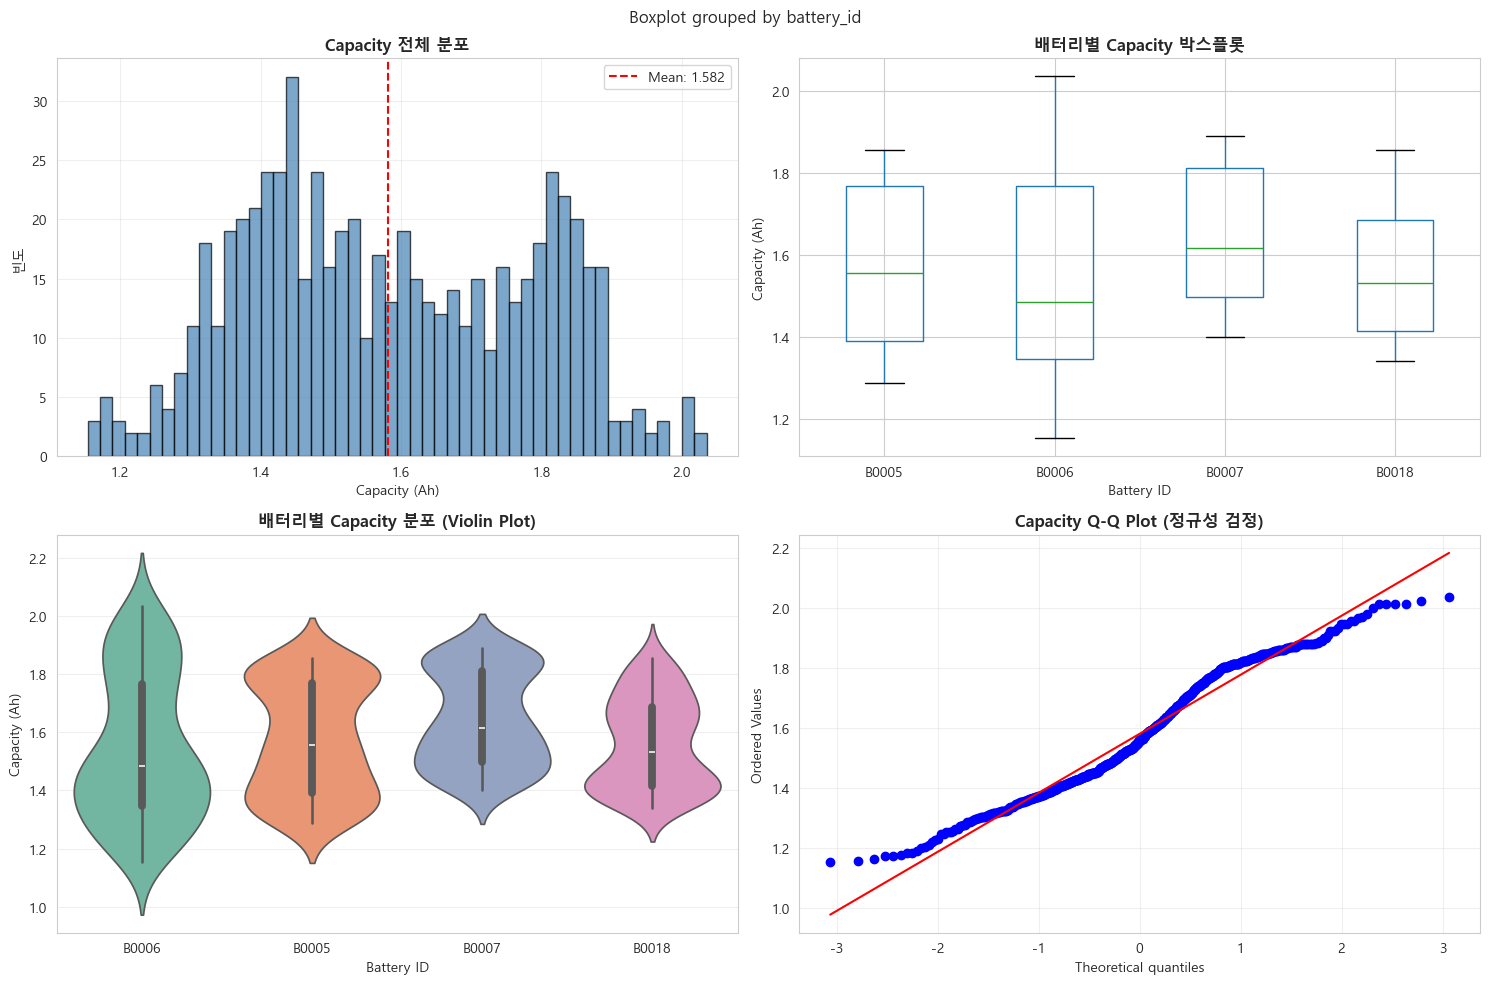

In [93]:
# Capacity 분포 시각화
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. 전체 분포
axes[0, 0].hist(capacity_data['Capacity'], bins=50, color='steelblue', alpha=0.7, edgecolor='black')
axes[0, 0].axvline(capacity_data['Capacity'].mean(), color='red', linestyle='--', label=f'Mean: {capacity_data["Capacity"].mean():.3f}')
axes[0, 0].set_title('Capacity 전체 분포', fontweight='bold')
axes[0, 0].set_xlabel('Capacity (Ah)')
axes[0, 0].set_ylabel('빈도')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# 2. 박스플롯 (배터리별)
capacity_data.boxplot(column='Capacity', by='battery_id', ax=axes[0, 1])
axes[0, 1].set_title('배터리별 Capacity 박스플롯', fontweight='bold')
axes[0, 1].set_xlabel('Battery ID')
axes[0, 1].set_ylabel('Capacity (Ah)')
plt.sca(axes[0, 1])
plt.xticks(rotation=0)

# 3. 바이올린 플롯
import seaborn as sns
sns.violinplot(data=capacity_data, x='battery_id', y='Capacity', ax=axes[1, 0], palette='Set2')
axes[1, 0].set_title('배터리별 Capacity 분포 (Violin Plot)', fontweight='bold')
axes[1, 0].set_xlabel('Battery ID')
axes[1, 0].set_ylabel('Capacity (Ah)')
axes[1, 0].grid(axis='y', alpha=0.3)

# 4. Q-Q Plot
from scipy import stats
stats.probplot(capacity_data['Capacity'], dist="norm", plot=axes[1, 1])
axes[1, 1].set_title('Capacity Q-Q Plot (정규성 검정)', fontweight='bold')
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [94]:
# IQR 방법으로 이상치 탐지
print("\n3️⃣ IQR 방법 이상치 탐지")
print("-" * 80)

Q1 = capacity_data['Capacity'].quantile(0.25)
Q3 = capacity_data['Capacity'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Q1 (25%): {Q1:.4f}")
print(f"Q3 (75%): {Q3:.4f}")
print(f"IQR: {IQR:.4f}")
print(f"하한선: {lower_bound:.4f}")
print(f"상한선: {upper_bound:.4f}")

# 이상치 개수
outliers_capacity = capacity_data[
    (capacity_data['Capacity'] < lower_bound) | 
    (capacity_data['Capacity'] > upper_bound)
]

print(f"\n이상치 개수: {len(outliers_capacity)} / {len(capacity_data)} ({len(outliers_capacity)/len(capacity_data)*100:.2f}%)")

if len(outliers_capacity) > 0:
    print("\n이상치 샘플:")
    print(outliers_capacity[['battery_id', 'type', 'test_id', 'Capacity']].head(10))


3️⃣ IQR 방법 이상치 탐지
--------------------------------------------------------------------------------
Q1 (25%): 1.4211
Q3 (75%): 1.7635
IQR: 0.3424
하한선: 0.9076
상한선: 2.2770

이상치 개수: 0 / 636 (0.00%)


### 5.2 Re, Rct 이상치 분석

In [95]:
# Re 데이터 분석
re_data = df[df['Re'].notna()].copy()

print("\n4️⃣ Re (전해질 저항) 이상치 분석")
print("-" * 80)
print(re_data['Re'].describe())

# IQR 방법
Q1_re = re_data['Re'].quantile(0.25)
Q3_re = re_data['Re'].quantile(0.75)
IQR_re = Q3_re - Q1_re
lower_re = Q1_re - 1.5 * IQR_re
upper_re = Q3_re + 1.5 * IQR_re

outliers_re = re_data[(re_data['Re'] < lower_re) | (re_data['Re'] > upper_re)]
print(f"\nRe 이상치: {len(outliers_re)} / {len(re_data)} ({len(outliers_re)/len(re_data)*100:.2f}%)")


4️⃣ Re (전해질 저항) 이상치 분석
--------------------------------------------------------------------------------
count   887.0000
mean      0.0593
std       0.0098
min       0.0359
25%       0.0506
50%       0.0596
75%       0.0658
max       0.0791
Name: Re, dtype: float64

Re 이상치: 0 / 887 (0.00%)


In [96]:
# Rct 데이터 분석
rct_data = df[df['Rct'].notna()].copy()

print("\n5️⃣ Rct (충전 전달 저항) 이상치 분석")
print("-" * 80)
print(rct_data['Rct'].describe())

# IQR 방법
Q1_rct = rct_data['Rct'].quantile(0.25)
Q3_rct = rct_data['Rct'].quantile(0.75)
IQR_rct = Q3_rct - Q1_rct
lower_rct = Q1_rct - 1.5 * IQR_rct
upper_rct = Q3_rct + 1.5 * IQR_rct

outliers_rct = rct_data[(rct_data['Rct'] < lower_rct) | (rct_data['Rct'] > upper_rct)]
print(f"\nRct 이상치: {len(outliers_rct)} / {len(rct_data)} ({len(outliers_rct)/len(rct_data)*100:.2f}%)")


5️⃣ Rct (충전 전달 저항) 이상치 분석
--------------------------------------------------------------------------------
count   887.0000
mean      0.0828
std       0.0104
min       0.0601
25%       0.0746
50%       0.0824
75%       0.0904
max       0.1067
Name: Rct, dtype: float64

Rct 이상치: 0 / 887 (0.00%)


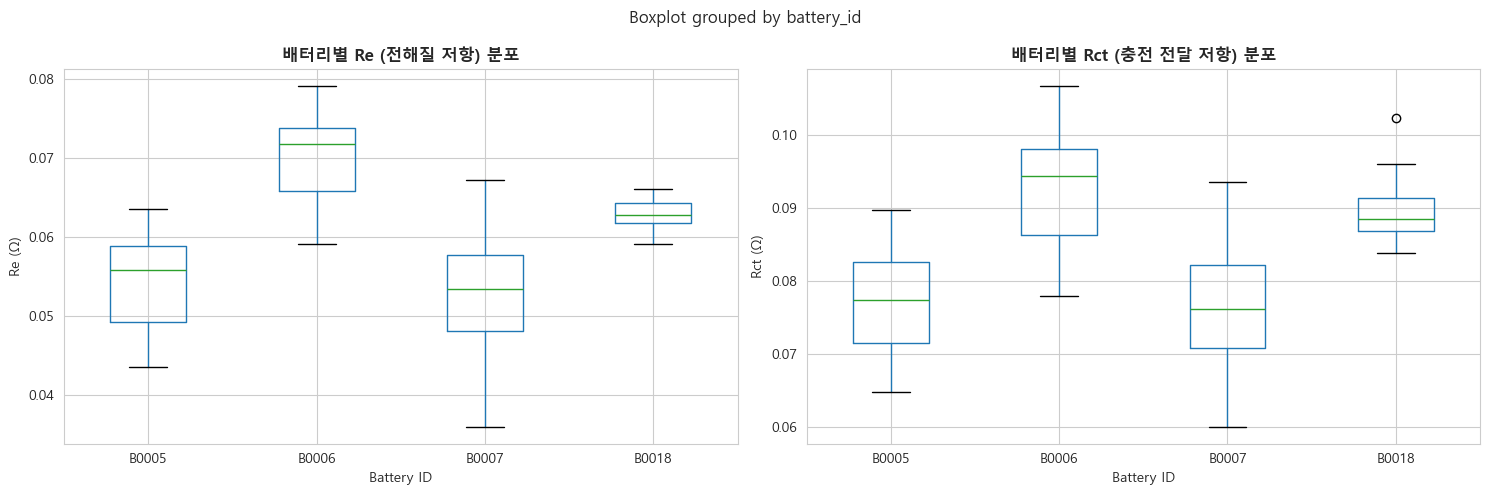

In [97]:
# Re, Rct 시각화
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Re 박스플롯
re_data.boxplot(column='Re', by='battery_id', ax=axes[0])
axes[0].set_title('배터리별 Re (전해질 저항) 분포', fontweight='bold')
axes[0].set_xlabel('Battery ID')
axes[0].set_ylabel('Re (Ω)')

# Rct 박스플롯
rct_data.boxplot(column='Rct', by='battery_id', ax=axes[1])
axes[1].set_title('배터리별 Rct (충전 전달 저항) 분포', fontweight='bold')
axes[1].set_xlabel('Battery ID')
axes[1].set_ylabel('Rct (Ω)')

plt.tight_layout()
plt.show()

### 5.3 이상치 처리 방침

In [98]:
print("\n💡 이상치 처리 방침")
print("="*80)
print("""\n✅ 이상치 유지 결정:
1. 배터리 열화는 자연스러운 물리적 현상이므로 극단값도 의미가 있음
2. 급격한 성능 저하는 배터리 상태 분석에 중요한 정보
3. 통계적 이상치가 실제 이상 배터리를 나타낼 수 있음
4. 데이터 크기가 충분하고 도메인 지식상 정상 범위로 판단

⚠️ 단, 다음과 같은 물리적으로 불가능한 값만 제거:
- Capacity < 0 (음수 용량)
- Re < 0 또는 Rct < 0 (음수 저항)
- 극단적으로 비정상적인 값 (예: Capacity > 5 Ah)
""")


💡 이상치 처리 방침

✅ 이상치 유지 결정:
1. 배터리 열화는 자연스러운 물리적 현상이므로 극단값도 의미가 있음
2. 급격한 성능 저하는 배터리 상태 분석에 중요한 정보
3. 통계적 이상치가 실제 이상 배터리를 나타낼 수 있음
4. 데이터 크기가 충분하고 도메인 지식상 정상 범위로 판단

⚠️ 단, 다음과 같은 물리적으로 불가능한 값만 제거:
- Capacity < 0 (음수 용량)
- Re < 0 또는 Rct < 0 (음수 저항)
- 극단적으로 비정상적인 값 (예: Capacity > 5 Ah)



In [99]:
# 물리적으로 불가능한 값 제거
print("\n🔧 물리적 불가능 값 제거")
print("-" * 80)

before_len = len(df)

# 음수 값 확인
negative_capacity = df[df['Capacity'] < 0]
negative_re = df[df['Re'] < 0]
negative_rct = df[df['Rct'] < 0]

print(f"음수 Capacity: {len(negative_capacity)}개")
print(f"음수 Re: {len(negative_re)}개")
print(f"음수 Rct: {len(negative_rct)}개")

# 극단값 확인 (Capacity > 3 Ah는 리튬이온 배터리로 비정상)
extreme_capacity = df[df['Capacity'] > 3]
print(f"극단 Capacity (> 3 Ah): {len(extreme_capacity)}개")

# 제거 (만약 있다면)
df = df[
    (df['Capacity'].isna()) | (df['Capacity'] >= 0) & (df['Capacity'] <= 3)
]
df = df[
    (df['Re'].isna()) | (df['Re'] >= 0)
]
df = df[
    (df['Rct'].isna()) | (df['Rct'] >= 0)
]

after_len = len(df)
removed = before_len - after_len

print(f"\n제거된 행: {removed}개")
print(f"남은 데이터: {after_len:,}개")

if removed == 0:
    print("\n✅ 물리적으로 불가능한 값이 없습니다!")


🔧 물리적 불가능 값 제거
--------------------------------------------------------------------------------
음수 Capacity: 0개
음수 Re: 0개
음수 Rct: 0개
극단 Capacity (> 3 Ah): 0개

제거된 행: 0개
남은 데이터: 2,167개

✅ 물리적으로 불가능한 값이 없습니다!


## 6. start_time 파싱

In [100]:
print("="*80)
print("📅 start_time 파싱")
print("="*80)

def parse_start_time(time_str):
    """
    start_time 문자열을 datetime으로 변환
    입력 예: '[2010. 7. 21. 15. 0. 35.093]'
    """
    try:
        # 문자열을 리스트로 변환
        time_list = ast.literal_eval(time_str)
        
        # datetime 생성
        return pd.Timestamp(
            year=int(time_list[0]),
            month=int(time_list[1]),
            day=int(time_list[2]),
            hour=int(time_list[3]),
            minute=int(time_list[4]),
            second=int(time_list[5]) if len(time_list) > 5 else 0
        )
    except:
        return pd.NaT

# start_time 파싱
df['start_datetime'] = df['start_time'].apply(parse_start_time)

print("✅ start_time 파싱 완료!")
print(f"\n변환 성공률: {(df['start_datetime'].notna().sum() / len(df) * 100):.2f}%")
print(f"\n샘플:")
print(df[['start_time', 'start_datetime']].head())

📅 start_time 파싱
✅ start_time 파싱 완료!

변환 성공률: 0.00%

샘플:
                                             start_time start_datetime
4504  [2.0080e+03 4.0000e+00 2.0000e+00 1.3000e+01 8...            NaT
4505  [2.0080e+03 4.0000e+00 2.0000e+00 1.5000e+01 2...            NaT
4506  [2.0080e+03 4.0000e+00 2.0000e+00 1.6000e+01 3...            NaT
4507  [2.0080e+03 4.0000e+00 2.0000e+00 1.9000e+01 4...            NaT
4508  [2.0080e+03 4.0000e+00 2.0000e+00 2.0000e+01 5...            NaT


## 7. 파생 컬럼 생성

### 7.1 Cycle 번호 생성

In [101]:
print("="*80)
print("🔄 Cycle 번호 생성")
print("="*80)

# 배터리별, test_id 기준으로 정렬
df = df.sort_values(['battery_id', 'test_id']).reset_index(drop=True)

# 배터리별로 cycle 번호 부여
df['Cycle'] = df.groupby('battery_id').cumcount()

print("✅ Cycle 번호 생성 완료!")
print(f"\n배터리별 최대 Cycle:")
print(df.groupby('battery_id')['Cycle'].max())

🔄 Cycle 번호 생성
✅ Cycle 번호 생성 완료!

배터리별 최대 Cycle:
battery_id
B0005    615
B0006    615
B0007    615
B0018    318
Name: Cycle, dtype: int64


### 7.2 Capacity 데이터 준비 (RUL, SOH 계산용)

In [102]:
# Capacity가 있는 데이터만 추출 (주로 discharge)
df_capacity = df[df['Capacity'].notna()].copy()

print(f"Capacity 데이터: {len(df_capacity)}개")
print(f"배터리별 Capacity 데이터 수:")
print(df_capacity['battery_id'].value_counts().sort_index())

Capacity 데이터: 636개
배터리별 Capacity 데이터 수:
battery_id
B0005    168
B0006    168
B0007    168
B0018    132
Name: count, dtype: int64


### 7.3 초기 용량 및 EOL 임계값 설정

In [103]:
print("="*80)
print("⚙️ 초기 용량 및 EOL 임계값 설정")
print("="*80)

# 배터리별 초기 용량 (첫 번째 Capacity 값)
initial_capacities = df_capacity.groupby('battery_id')['Capacity'].first()

print("\n배터리별 초기 용량:")
for battery_id, initial_cap in initial_capacities.items():
    eol_threshold = initial_cap * 0.8
    print(f"{battery_id}: {initial_cap:.4f} Ah → EOL 임계값: {eol_threshold:.4f} Ah (80%)")

⚙️ 초기 용량 및 EOL 임계값 설정

배터리별 초기 용량:
B0005: 1.8565 Ah → EOL 임계값: 1.4852 Ah (80%)
B0006: 2.0353 Ah → EOL 임계값: 1.6283 Ah (80%)
B0007: 1.8911 Ah → EOL 임계값: 1.5128 Ah (80%)
B0018: 1.8550 Ah → EOL 임계값: 1.4840 Ah (80%)


### 7.4 RUL (Remaining Useful Life) 계산

In [104]:
print("="*80)
print("🔋 RUL (잔존 수명) 계산")
print("="*80)

def calculate_rul_and_eol(battery_df):
    """
    배터리별 RUL 및 EOL 계산
    
    Args:
        battery_df: 특정 배터리의 Capacity 데이터
    
    Returns:
        RUL, EOL 정보가 추가된 DataFrame
    """
    # 정렬
    battery_df = battery_df.sort_values('test_id').reset_index(drop=True)
    
    # 초기 용량
    initial_capacity = battery_df['Capacity'].iloc[0]
    eol_threshold = initial_capacity * 0.8  # 80% 기준
    
    # EOL 사이클 찾기 (용량이 80% 이하로 떨어진 첫 지점)
    eol_indices = battery_df[battery_df['Capacity'] <= eol_threshold].index
    
    if len(eol_indices) > 0:
        eol_cycle = eol_indices[0]
    else:
        # EOL에 도달하지 않은 경우 마지막 사이클을 EOL로 설정
        eol_cycle = len(battery_df) - 1
    
    # Cycle 번호 (0부터 시작)
    battery_df['Capacity_Cycle'] = range(len(battery_df))
    
    # RUL 계산 (EOL - 현재 사이클)
    battery_df['RUL'] = eol_cycle - battery_df['Capacity_Cycle']
    battery_df['RUL'] = battery_df['RUL'].clip(lower=0)  # 음수 방지
    
    # 추가 정보
    battery_df['Initial_Capacity'] = initial_capacity
    battery_df['EOL_Threshold'] = eol_threshold
    battery_df['EOL_Cycle'] = eol_cycle
    
    return battery_df

# 배터리별로 RUL 계산
df_with_rul = pd.DataFrame()

for battery_id in TARGET_BATTERIES:
    battery_data = df_capacity[df_capacity['battery_id'] == battery_id].copy()
    
    if len(battery_data) > 0:
        battery_with_rul = calculate_rul_and_eol(battery_data)
        df_with_rul = pd.concat([df_with_rul, battery_with_rul], ignore_index=True)
        
        print(f"\n{battery_id}:")
        print(f"  초기 용량: {battery_with_rul['Initial_Capacity'].iloc[0]:.4f} Ah")
        print(f"  EOL 임계값: {battery_with_rul['EOL_Threshold'].iloc[0]:.4f} Ah")
        print(f"  EOL 사이클: {battery_with_rul['EOL_Cycle'].iloc[0]}")
        print(f"  현재 최소 RUL: {battery_with_rul['RUL'].min()}")

print(f"\n✅ RUL 계산 완료! ({len(df_with_rul)}개 데이터)")

🔋 RUL (잔존 수명) 계산

B0005:
  초기 용량: 1.8565 Ah
  EOL 임계값: 1.4852 Ah
  EOL 사이클: 100
  현재 최소 RUL: 0

B0006:
  초기 용량: 2.0353 Ah
  EOL 임계값: 1.6283 Ah
  EOL 사이클: 60
  현재 최소 RUL: 0

B0007:
  초기 용량: 1.8911 Ah
  EOL 임계값: 1.5128 Ah
  EOL 사이클: 123
  현재 최소 RUL: 0

B0018:
  초기 용량: 1.8550 Ah
  EOL 임계값: 1.4840 Ah
  EOL 사이클: 74
  현재 최소 RUL: 0

✅ RUL 계산 완료! (636개 데이터)


In [105]:
# RUL 데이터 미리보기
print("\n📋 RUL 계산 결과 샘플:")
df_with_rul[['battery_id', 'type', 'Capacity', 'Capacity_Cycle', 'RUL', 'EOL_Cycle']].head(15)


📋 RUL 계산 결과 샘플:


,battery_id,type,Capacity,Capacity_Cycle,RUL,EOL_Cycle
0,B0005,discharge,1.8565,0,100,100
1,B0005,discharge,1.8463,1,99,100
2,B0005,discharge,1.8353,2,98,100
3,B0005,discharge,1.8353,3,97,100
4,B0005,discharge,1.8346,4,96,100
5,B0005,discharge,1.8357,5,95,100
6,B0005,discharge,1.8351,6,94,100
7,B0005,discharge,1.8258,7,93,100
8,B0005,discharge,1.8248,8,92,100
9,B0005,discharge,1.8246,9,91,100


### 7.5 SOH (State of Health) 계산

In [106]:
print("="*80)
print("💊 SOH (State of Health) 계산")
print("="*80)

# SOH = (현재 용량 / 초기 용량) × 100
df_with_rul['SOH'] = (df_with_rul['Capacity'] / df_with_rul['Initial_Capacity'] * 100).round(2)

print("\n✅ SOH 계산 완료!")
print("\n배터리별 SOH 통계:")
print(df_with_rul.groupby('battery_id')['SOH'].describe().round(2))

💊 SOH (State of Health) 계산

✅ SOH 계산 완료!

배터리별 SOH 통계:
              count    mean     std     min     25%     50%     75%      max
battery_id                                                                  
B0005      168.0000 84.7000 10.2600 69.3500 74.8700 83.8700 95.3000 100.0000
B0006      168.0000 76.0000 12.3800 56.6900 66.2000 72.9800 86.8200 100.0000
B0007      168.0000 86.9600  8.5100 74.0600 79.2200 85.4600 95.8200 100.0000
B0018      132.0000 83.9700  8.3500 72.2900 76.2900 82.5800 90.8300 100.0000


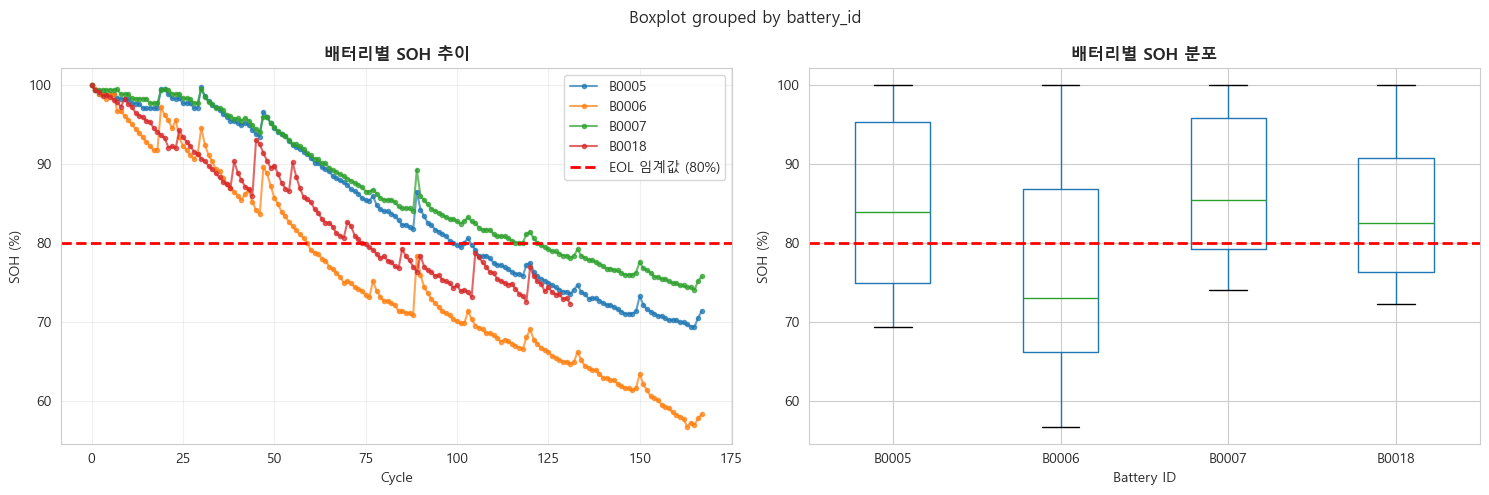

In [107]:
# SOH 분포 시각화
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 1. 배터리별 SOH 추이
for battery_id in TARGET_BATTERIES:
    battery_data = df_with_rul[df_with_rul['battery_id'] == battery_id]
    axes[0].plot(battery_data['Capacity_Cycle'], battery_data['SOH'], 
                label=battery_id, marker='o', markersize=3, alpha=0.7)

axes[0].axhline(y=80, color='red', linestyle='--', label='EOL 임계값 (80%)', linewidth=2)
axes[0].set_title('배터리별 SOH 추이', fontweight='bold', fontsize=12)
axes[0].set_xlabel('Cycle')
axes[0].set_ylabel('SOH (%)')
axes[0].legend()
axes[0].grid(alpha=0.3)

# 2. 배터리별 SOH 박스플롯
df_with_rul.boxplot(column='SOH', by='battery_id', ax=axes[1])
axes[1].axhline(y=80, color='red', linestyle='--', linewidth=2)
axes[1].set_title('배터리별 SOH 분포', fontweight='bold', fontsize=12)
axes[1].set_xlabel('Battery ID')
axes[1].set_ylabel('SOH (%)')
plt.sca(axes[1])
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

### 7.6 배터리 상태 분류 (Status)

In [108]:
print("="*80)
print("🚦 배터리 상태 분류")
print("="*80)

def classify_battery_status(row):
    """
    배터리 상태 분류
    - 위험: RUL < 10 또는 SOH < 80%
    - 주의: 80% ≤ SOH < 90%
    - 안정: SOH ≥ 90%
    """
    if row['RUL'] < 10 or row['SOH'] < 80:
        return '위험'
    elif row['SOH'] < 90:
        return '주의'
    else:
        return '안정'

df_with_rul['Status'] = df_with_rul.apply(classify_battery_status, axis=1)

print("\n✅ 상태 분류 완료!")
print("\n전체 상태 분포:")
status_counts = df_with_rul['Status'].value_counts()
print(status_counts)
print(f"\n비율:")
print((status_counts / len(df_with_rul) * 100).round(2))

🚦 배터리 상태 분류

✅ 상태 분류 완료!

전체 상태 분포:
Status
위험    315
안정    200
주의    121
Name: count, dtype: int64

비율:
Status
위험   49.5300
안정   31.4500
주의   19.0300
Name: count, dtype: float64



배터리별 상태 분포:
Status      안정   위험  주의
battery_id             
B0005       63   77  28
B0006       34  117  17
B0007       65   54  49
B0018       38   67  27


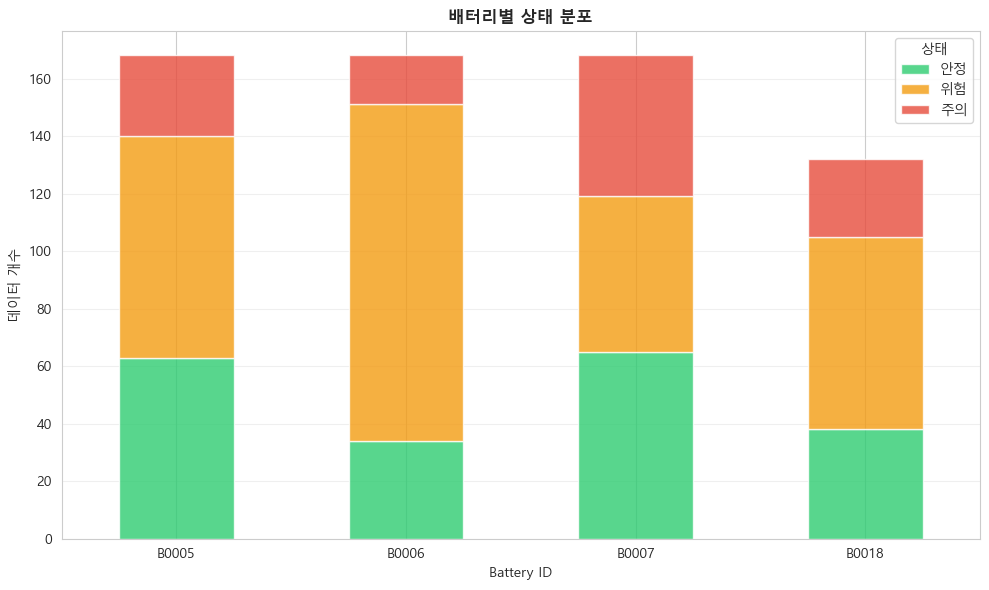

In [109]:
# 배터리별 상태 분포
print("\n배터리별 상태 분포:")
status_by_battery = pd.crosstab(df_with_rul['battery_id'], df_with_rul['Status'])
print(status_by_battery)

# 시각화
status_by_battery.plot(kind='bar', stacked=True, figsize=(10, 6), 
                       color=['#2ecc71', '#f39c12', '#e74c3c'], alpha=0.8)
plt.title('배터리별 상태 분포', fontweight='bold', fontsize=12)
plt.xlabel('Battery ID')
plt.ylabel('데이터 개수')
plt.legend(title='상태')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 8. 최종 데이터셋 생성

In [110]:
print("="*80)
print("📦 최종 데이터셋 생성")
print("="*80)

# 컬럼 정리
final_columns = [
    'battery_id', 'type', 'test_id', 'uid', 'filename',
    'start_time', 'start_datetime',
    'ambient_temperature',
    'Cycle',
    'Capacity', 'Capacity_Cycle',
    'Re', 'Rct',
    'Initial_Capacity', 'EOL_Threshold', 'EOL_Cycle',
    'RUL', 'SOH', 'Status'
]

# 최종 데이터셋
df_final = df_with_rul[final_columns].copy()

print(f"\n최종 데이터셋 크기: {df_final.shape}")
print(f"컬럼 개수: {len(df_final.columns)}")
print(f"\n컬럼 리스트:")
for i, col in enumerate(df_final.columns, 1):
    print(f"{i:2d}. {col}")

📦 최종 데이터셋 생성

최종 데이터셋 크기: (636, 19)
컬럼 개수: 19

컬럼 리스트:
 1. battery_id
 2. type
 3. test_id
 4. uid
 5. filename
 6. start_time
 7. start_datetime
 8. ambient_temperature
 9. Cycle
10. Capacity
11. Capacity_Cycle
12. Re
13. Rct
14. Initial_Capacity
15. EOL_Threshold
16. EOL_Cycle
17. RUL
18. SOH
19. Status


In [111]:
# 최종 데이터 미리보기
print("\n📋 최종 데이터 미리보기:")
df_final.head(10)


📋 최종 데이터 미리보기:


,battery_id,type,test_id,uid,filename,start_time,start_datetime,ambient_temperature,Cycle,Capacity,Capacity_Cycle,Re,Rct,Initial_Capacity,EOL_Threshold,EOL_Cycle,RUL,SOH,Status
0,B0005,discharge,1,5122,05122.csv,[2.0080e+03 4.0000e+00 2.0000e+00 1.5000e+01 2...,NaT,24,1,1.8565,0,NaN,NaN,1.8565,1.4852,100,100,100.0000,안정
1,B0005,discharge,3,5124,05124.csv,[2.0080e+03 4.0000e+00 2.0000e+00 1.9000e+01 4...,NaT,24,3,1.8463,1,NaN,NaN,1.8565,1.4852,100,99,99.4500,안정
2,B0005,discharge,5,5126,05126.csv,[2.008e+03 4.000e+00 3.000e+00 0.000e+00 1.000...,NaT,24,5,1.8353,2,NaN,NaN,1.8565,1.4852,100,98,98.8600,안정
3,B0005,discharge,7,5128,05128.csv,[2008. 4. 3. 4. 16. ...,NaT,24,7,1.8353,3,NaN,NaN,1.8565,1.4852,100,97,98.8600,안정
4,B0005,discharge,9,5130,05130.csv,[2008. 4. 3. 8. 33. ...,NaT,24,9,1.8346,4,NaN,NaN,1.8565,1.4852,100,96,98.8200,안정
5,B0005,discharge,11,5132,05132.csv,[2008. 4. 3. 12. 55. ...,NaT,24,11,1.8357,5,NaN,NaN,1.8565,1.4852,100,95,98.8800,안정
6,B0005,discharge,13,5134,05134.csv,[2008. 4. 3. 17. 17. ...,NaT,24,13,1.8351,6,NaN,NaN,1.8565,1.4852,100,94,98.8500,안정
7,B0005,discharge,15,5136,05136.csv,[2008. 4. 3. 21. 28. ...,NaT,24,15,1.8258,7,NaN,NaN,1.8565,1.4852,100,93,98.3400,안정
8,B0005,discharge,17,5138,05138.csv,[2.0080e+03 4.0000e+00 4.0000e+00 1.0000e+00 3...,NaT,24,17,1.8248,8,NaN,NaN,1.8565,1.4852,100,92,98.2900,안정
9,B0005,discharge,19,5140,05140.csv,[2008. 4. 4. 5. 48. ...,NaT,24,19,1.8246,9,NaN,NaN,1.8565,1.4852,100,91,98.2800,안정


In [112]:
# 최종 데이터 요약 통계
print("\n📊 최종 데이터 요약 통계:")
print("\n배터리별 데이터 개수:")
print(df_final['battery_id'].value_counts().sort_index())

print("\nType별 분포:")
print(df_final['type'].value_counts())

print("\n상태별 분포:")
print(df_final['Status'].value_counts())

print("\n주요 지표 통계:")
print(df_final[['Capacity', 'SOH', 'RUL']].describe().round(2))


📊 최종 데이터 요약 통계:

배터리별 데이터 개수:
battery_id
B0005    168
B0006    168
B0007    168
B0018    132
Name: count, dtype: int64

Type별 분포:
type
discharge    636
Name: count, dtype: int64

상태별 분포:
Status
위험    315
안정    200
주의    121
Name: count, dtype: int64

주요 지표 통계:
       Capacity      SOH      RUL
count  636.0000 636.0000 636.0000
mean     1.5800  82.8500  27.1700
std      0.2000  10.9300  33.4000
min      1.1500  56.6900   0.0000
25%      1.4200  74.8100   0.0000
50%      1.5600  82.3200  10.0000
75%      1.7600  92.5200  50.0000
max      2.0400 100.0000 123.0000


## 9. 데이터 품질 최종 검증

In [113]:
print("="*80)
print("✅ 데이터 품질 최종 검증")
print("="*80)

# 1. 결측치 확인
print("\n1️⃣ 결측치 확인:")
missing_final = df_final.isnull().sum()
if missing_final.sum() > 0:
    print(missing_final[missing_final > 0])
else:
    print("✅ 결측치 없음!")

# 2. 중복 확인
print("\n2️⃣ 중복 확인:")
duplicates = df_final.duplicated(subset=['battery_id', 'test_id']).sum()
print(f"중복 행: {duplicates}개")
if duplicates == 0:
    print("✅ 중복 없음!")

# 3. 데이터 타입 확인
print("\n3️⃣ 데이터 타입 확인:")
print(df_final.dtypes)

# 4. 범위 확인
print("\n4️⃣ 주요 지표 범위 확인:")
print(f"Capacity: {df_final['Capacity'].min():.4f} ~ {df_final['Capacity'].max():.4f} Ah")
print(f"SOH: {df_final['SOH'].min():.2f}% ~ {df_final['SOH'].max():.2f}%")
print(f"RUL: {df_final['RUL'].min()} ~ {df_final['RUL'].max()}")

# 5. 논리적 일관성 확인
print("\n5️⃣ 논리적 일관성 확인:")
inconsistent = df_final[df_final['Capacity'] > df_final['Initial_Capacity']]
print(f"현재 용량 > 초기 용량 (비정상): {len(inconsistent)}개")
if len(inconsistent) == 0:
    print("✅ 논리적 일관성 확인 완료!")

✅ 데이터 품질 최종 검증

1️⃣ 결측치 확인:
start_datetime    636
Re                636
Rct               636
dtype: int64

2️⃣ 중복 확인:
중복 행: 0개
✅ 중복 없음!

3️⃣ 데이터 타입 확인:
battery_id                     object
type                           object
test_id                         int64
uid                             int64
filename                       object
start_time                     object
start_datetime         datetime64[ns]
ambient_temperature             int64
Cycle                           int64
Capacity                      float64
Capacity_Cycle                  int64
Re                            float64
Rct                           float64
Initial_Capacity              float64
EOL_Threshold                 float64
EOL_Cycle                       int64
RUL                             int64
SOH                           float64
Status                         object
dtype: object

4️⃣ 주요 지표 범위 확인:
Capacity: 1.1538 ~ 2.0353 Ah
SOH: 56.69% ~ 100.00%
RUL: 0 ~ 123

5️⃣ 논리적 일관성 확인:
현재 용량 > 초기 용

## 10. 클린 데이터셋 저장

In [114]:
print("="*80)
print("💾 클린 데이터셋 저장")
print("="*80)

# 현재 폴더에 저장
output_path = 'battery_clean_data.csv'

try:
    df_final.to_csv(output_path, index=False, encoding='utf-8-sig')
    print(f"\n✅ 저장 완료!")
    print(f"   파일명: {output_path}")
    print(f"   크기: {df_final.shape}")
except PermissionError as e:
    print(f"\n❌ 저장 실패: {e}")
    print("   → Excel에서 파일을 닫아주세요.")

print("\n" + "="*80)
print("✅ 전처리 완료!")
print("="*80)

💾 클린 데이터셋 저장

✅ 저장 완료!
   파일명: battery_clean_data.csv
   크기: (636, 19)

✅ 전처리 완료!


## 11. 전처리 결과 시각화 요약

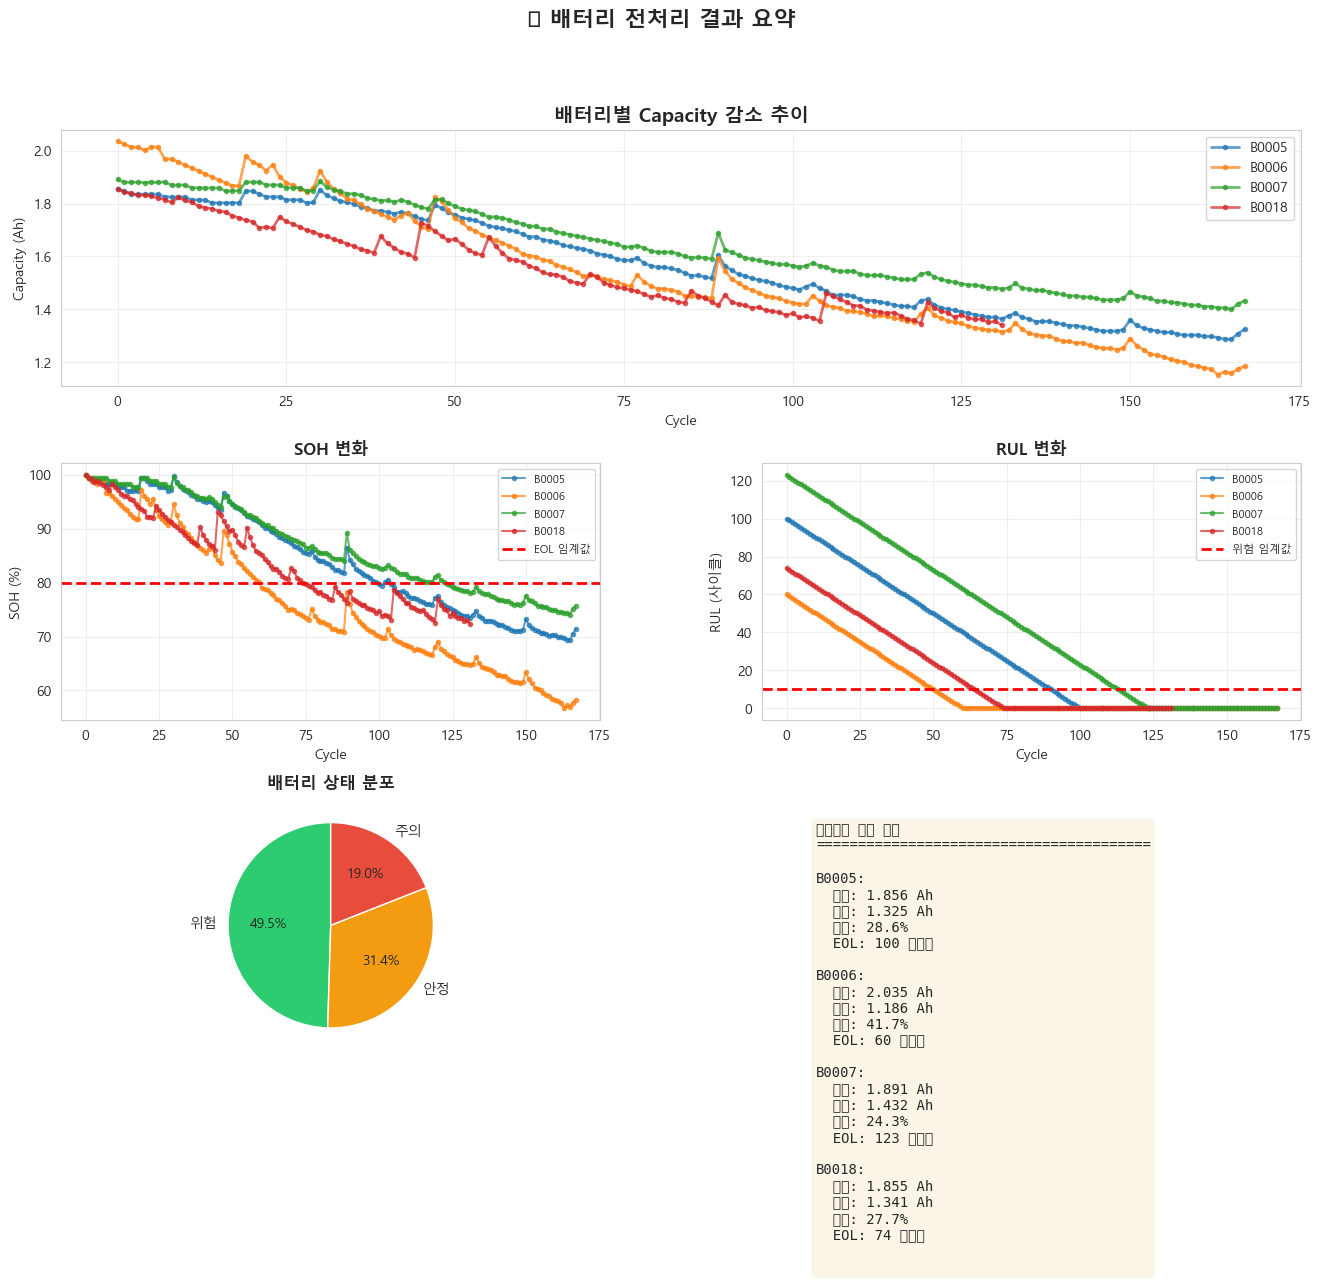

In [115]:
# 최종 결과 종합 시각화
fig = plt.figure(figsize=(16, 12))
gs = fig.add_gridspec(3, 2, hspace=0.3, wspace=0.3)

# 1. Capacity 추이
ax1 = fig.add_subplot(gs[0, :])
for battery_id in TARGET_BATTERIES:
    data = df_final[df_final['battery_id'] == battery_id]
    ax1.plot(data['Capacity_Cycle'], data['Capacity'], 
            label=battery_id, marker='o', markersize=3, alpha=0.7, linewidth=2)
ax1.set_title('배터리별 Capacity 감소 추이', fontweight='bold', fontsize=14)
ax1.set_xlabel('Cycle')
ax1.set_ylabel('Capacity (Ah)')
ax1.legend(loc='best')
ax1.grid(alpha=0.3)

# 2. SOH 추이
ax2 = fig.add_subplot(gs[1, 0])
for battery_id in TARGET_BATTERIES:
    data = df_final[df_final['battery_id'] == battery_id]
    ax2.plot(data['Capacity_Cycle'], data['SOH'], 
            label=battery_id, marker='o', markersize=3, alpha=0.7)
ax2.axhline(y=80, color='red', linestyle='--', linewidth=2, label='EOL 임계값')
ax2.set_title('SOH 변화', fontweight='bold', fontsize=12)
ax2.set_xlabel('Cycle')
ax2.set_ylabel('SOH (%)')
ax2.legend(loc='best', fontsize=8)
ax2.grid(alpha=0.3)

# 3. RUL 추이
ax3 = fig.add_subplot(gs[1, 1])
for battery_id in TARGET_BATTERIES:
    data = df_final[df_final['battery_id'] == battery_id]
    ax3.plot(data['Capacity_Cycle'], data['RUL'], 
            label=battery_id, marker='o', markersize=3, alpha=0.7)
ax3.axhline(y=10, color='red', linestyle='--', linewidth=2, label='위험 임계값')
ax3.set_title('RUL 변화', fontweight='bold', fontsize=12)
ax3.set_xlabel('Cycle')
ax3.set_ylabel('RUL (사이클)')
ax3.legend(loc='best', fontsize=8)
ax3.grid(alpha=0.3)

# 4. 상태 분포 (파이차트)
ax4 = fig.add_subplot(gs[2, 0])
status_counts = df_final['Status'].value_counts()
colors = ['#2ecc71', '#f39c12', '#e74c3c']
ax4.pie(status_counts, labels=status_counts.index, autopct='%1.1f%%',
       colors=colors, startangle=90)
ax4.set_title('배터리 상태 분포', fontweight='bold', fontsize=12)

# 5. 배터리별 최종 통계
ax5 = fig.add_subplot(gs[2, 1])
ax5.axis('off')

summary_text = "배터리별 최종 통계\n" + "="*40 + "\n\n"
for battery_id in TARGET_BATTERIES:
    data = df_final[df_final['battery_id'] == battery_id]
    initial = data['Initial_Capacity'].iloc[0]
    final = data['Capacity'].iloc[-1]
    degradation = (1 - final/initial) * 100
    eol = data['EOL_Cycle'].iloc[0]
    
    summary_text += f"{battery_id}:\n"
    summary_text += f"  초기: {initial:.3f} Ah\n"
    summary_text += f"  최종: {final:.3f} Ah\n"
    summary_text += f"  감소: {degradation:.1f}%\n"
    summary_text += f"  EOL: {eol} 사이클\n\n"

ax5.text(0.1, 0.9, summary_text, transform=ax5.transAxes,
        fontsize=10, verticalalignment='top', fontfamily='monospace',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))

plt.suptitle('🔋 배터리 전처리 결과 요약', fontsize=16, fontweight='bold', y=0.98)
plt.show()

## 12. 전처리 프로세스 요약

In [116]:
print("="*80)
print("📋 전처리 프로세스 요약")
print("="*80)

summary = f"""
✅ 완료된 작업:

1. 데이터 로드 및 필터링
   - 원본 데이터: {len(df_raw):,}개
   - 타겟 배터리 추출: {len(df):,}개
   - 최종 분석 데이터: {len(df_final):,}개

2. 결측치 처리
   - Capacity, Re, Rct의 결측은 도메인 지식상 정상 (type별 측정 차이)
   - 처리 방침: 결측 유지 (분석 시 type별 필터링 필요)

3. 이상치 처리
   - 물리적 불가능 값 제거 (음수, 극단값)
   - 통계적 이상치는 유지 (배터리 열화 특성상 의미 있는 데이터)

4. 파생 컬럼 생성
   ✓ Cycle: 배터리별 사이클 번호 (0부터 시작)
   ✓ Capacity_Cycle: Capacity 기준 사이클 번호
   ✓ Initial_Capacity: 배터리별 초기 용량
   ✓ EOL_Threshold: 수명 종료 임계값 (초기 용량의 80%)
   ✓ EOL_Cycle: EOL 도달 사이클
   ✓ RUL: 잔존 수명 (Remaining Useful Life)
   ✓ SOH: 건강 상태 (State of Health, %)
   ✓ Status: 배터리 상태 분류 (안정/주의/위험)

5. 데이터 품질 검증
   ✓ 중복 확인: 없음
   ✓ 논리적 일관성: 확인 완료
   ✓ 데이터 타입: 적절히 변환

6. 파일 저장
   ✓ battery_clean_data.csv: Tableau 분석용 클린 데이터셋

📊 다음 단계:
   → battery_clean_data.csv를 Tableau에 로드
   → 대시보드 설계 및 구축
   → 인사이트 도출 및 스토리텔링
"""

print(summary)
print("="*80)

📋 전처리 프로세스 요약

✅ 완료된 작업:

1. 데이터 로드 및 필터링
   - 원본 데이터: 7,565개
   - 타겟 배터리 추출: 2,167개
   - 최종 분석 데이터: 636개

2. 결측치 처리
   - Capacity, Re, Rct의 결측은 도메인 지식상 정상 (type별 측정 차이)
   - 처리 방침: 결측 유지 (분석 시 type별 필터링 필요)

3. 이상치 처리
   - 물리적 불가능 값 제거 (음수, 극단값)
   - 통계적 이상치는 유지 (배터리 열화 특성상 의미 있는 데이터)

4. 파생 컬럼 생성
   ✓ Cycle: 배터리별 사이클 번호 (0부터 시작)
   ✓ Capacity_Cycle: Capacity 기준 사이클 번호
   ✓ Initial_Capacity: 배터리별 초기 용량
   ✓ EOL_Threshold: 수명 종료 임계값 (초기 용량의 80%)
   ✓ EOL_Cycle: EOL 도달 사이클
   ✓ RUL: 잔존 수명 (Remaining Useful Life)
   ✓ SOH: 건강 상태 (State of Health, %)
   ✓ Status: 배터리 상태 분류 (안정/주의/위험)

5. 데이터 품질 검증
   ✓ 중복 확인: 없음
   ✓ 논리적 일관성: 확인 완료
   ✓ 데이터 타입: 적절히 변환

6. 파일 저장
   ✓ battery_clean_data.csv: Tableau 분석용 클린 데이터셋

📊 다음 단계:
   → battery_clean_data.csv를 Tableau에 로드
   → 대시보드 설계 및 구축
   → 인사이트 도출 및 스토리텔링



## 13. Impedance 데이터 분석 (Re, Rct 추가 분석)


In [117]:
print("="*80)
print("🔌 Impedance 데이터 분석 (Re, Rct)")
print("="*80)

# Impedance 데이터 추출 (Re 또는 Rct가 있는 데이터)
df_impedance = df[(df['Re'].notna()) | (df['Rct'].notna())].copy()

print(f"Impedance 데이터: {len(df_impedance)}개")
print(f"배터리별 Impedance 데이터 수:")
print(df_impedance['battery_id'].value_counts().sort_index())

# Re 데이터만 추출
df_re = df[df['Re'].notna()].copy()
print(f"\nRe 데이터: {len(df_re)}개")

# Rct 데이터만 추출
df_rct = df[df['Rct'].notna()].copy()
print(f"Rct 데이터: {len(df_rct)}개")

🔌 Impedance 데이터 분석 (Re, Rct)
Impedance 데이터: 887개
배터리별 Impedance 데이터 수:
battery_id
B0005    278
B0006    278
B0007    278
B0018     53
Name: count, dtype: int64

Re 데이터: 887개
Rct 데이터: 887개
